In [1]:
%pip install biopython
%pip install datasets
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Extracting Data from Dataset
Getting the data from the dataset and then converting it to a dataframe so it is easy to access

In [3]:
db = load_dataset("tattabio/modac_paralogy_bigene")
print(db)

DatasetDict({
    train: Dataset({
        features: ['ID1', 'Seq1', 'ID2', 'Seq2'],
        num_rows: 1492
    })
})


In [4]:
pos_data = db['train']

pos_data = pos_data.to_pandas()
pos_data['label'] = 1
print(pos_data)

         ID1                                               Seq1     ID2  \
0     E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1     D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2     C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3     C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4     C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   
...      ...                                                ...     ...   
1487  Q1LU07  MSITIENVSKFFDNTQVLNNISLDINSGQMVALLGPSGSGKTTLLR...  Q1LU08   
1488  C7MHE4  MNSVDLENVTKIYSGSTPSVDDVSLTVGDGEFFTLLGPSGCGKSTT...  C7MHE5   
1489  C7MHQ3  MITFDDITVRFGQFTALPSLSLNIDEGEFFTLLGPSGCGKSTALRT...  C7MHQ2   
1490  Q2CC48  MTELSLRGLTKRFGNHTAVDDVTLDVPDGSFICLLGPSGCGKTTLL...  Q2CC47   
1491  Q2CJ49  MASVEISGLRKLYADVVALEDINLSIPTGSFYTLLGPSGCGKTTLL...  Q2CJ48   

                                                   Seq2  label  
0     MPSRTRLRMSDKSRNWYLIPYTAWIVLF

# Creating the extra N rows
This is so that there is negative data for the model to see as well so that it can make more accurate predictions later on

In [5]:
neg_data = pos_data.copy()
shuffle = pos_data[['ID2', 'Seq2']].sample(frac=1).reset_index(drop=True)
neg_data['ID2'] = shuffle['ID2']
neg_data['Seq2'] = shuffle['Seq2']
neg_data['label'] = 0
print(neg_data)

         ID1                                               Seq1     ID2  \
0     E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  B8G8L4   
1     D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D0LJQ6   
2     C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C8NEB6   
3     C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  Q0YP64   
4     C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  A6X2P5   
...      ...                                                ...     ...   
1487  Q1LU07  MSITIENVSKFFDNTQVLNNISLDINSGQMVALLGPSGSGKTTLLR...  E8UYC6   
1488  C7MHE4  MNSVDLENVTKIYSGSTPSVDDVSLTVGDGEFFTLLGPSGCGKSTT...  E0I7Z2   
1489  C7MHQ3  MITFDDITVRFGQFTALPSLSLNIDEGEFFTLLGPSGCGKSTALRT...  A4F793   
1490  Q2CC48  MTELSLRGLTKRFGNHTAVDDVTLDVPDGSFICLLGPSGCGKTTLL...  E6U585   
1491  Q2CJ49  MASVEISGLRKLYADVVALEDINLSIPTGSFYTLLGPSGCGKTTLL...  E9SWW4   

                                                   Seq2  label  
0     MNWPAFWLSLQVTAVATFFIWLLGLPIA

# Joining the positive and negative data to get a final database

In [6]:
final_db = pd.concat([pos_data, neg_data], axis=0)
print(final_db)

         ID1                                               Seq1     ID2  \
0     E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1     D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2     C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3     C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4     C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   
...      ...                                                ...     ...   
1487  Q1LU07  MSITIENVSKFFDNTQVLNNISLDINSGQMVALLGPSGSGKTTLLR...  E8UYC6   
1488  C7MHE4  MNSVDLENVTKIYSGSTPSVDDVSLTVGDGEFFTLLGPSGCGKSTT...  E0I7Z2   
1489  C7MHQ3  MITFDDITVRFGQFTALPSLSLNIDEGEFFTLLGPSGCGKSTALRT...  A4F793   
1490  Q2CC48  MTELSLRGLTKRFGNHTAVDDVTLDVPDGSFICLLGPSGCGKTTLL...  E6U585   
1491  Q2CJ49  MASVEISGLRKLYADVVALEDINLSIPTGSFYTLLGPSGCGKTTLL...  E9SWW4   

                                                   Seq2  label  
0     MPSRTRLRMSDKSRNWYLIPYTAWIVLF

# Creating the features for each sequence

In [7]:
def get_features(seq):
  # Amino acids composition
  analyzed_seq = ProteinAnalysis(seq.replace("X","").replace("Z",""))
  aa_comp = list(analyzed_seq.amino_acids_percent.values())

  # Dipeptide frequency
  aa = 'ACDEFGHIKLMNPQRSTVWY'
  dipeptides = {a+b:0 for a in aa for b in aa}

  for i in range(len(seq) - 1):
    pair = seq[i:i+2]
    if pair in dipeptides:
      dipeptides[pair] += 1

  dipeptide_freq = [count / (len(seq) - 1) for count in dipeptides.values()]

  # Physicochemical descriptors
  phys_desc = [
      analyzed_seq.gravy(),
      analyzed_seq.isoelectric_point(),
      analyzed_seq.molecular_weight(),
      analyzed_seq.aromaticity()
  ]

  return aa_comp + dipeptide_freq + phys_desc

In [8]:
f1_list = []
f2_list = []

for index, row in final_db.iterrows():
    f1 = get_features(row['Seq1'])
    f2 = get_features(row['Seq2'])

    f1_list.append(f1)
    f2_list.append(f2)


aa_names = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
dipep_names = [f"dp_{i}" for i in range(400)]
phys_names = ['gravy', 'isoelectric_point', 'mol_weight', 'aromaticity']

header = aa_names + dipep_names + phys_names

df_features1 = pd.DataFrame(f1_list, columns=[f"s1_{name}" for name in header])
df_features2 = pd.DataFrame(f2_list, columns=[f"s2_{name}" for name in header])

final_db = pd.concat([final_db.reset_index(drop=True), df_features1, df_features2], axis=1)

print(final_db)

         ID1                                               Seq1     ID2  \
0     E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1     D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2     C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3     C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4     C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   
...      ...                                                ...     ...   
2979  Q1LU07  MSITIENVSKFFDNTQVLNNISLDINSGQMVALLGPSGSGKTTLLR...  E8UYC6   
2980  C7MHE4  MNSVDLENVTKIYSGSTPSVDDVSLTVGDGEFFTLLGPSGCGKSTT...  E0I7Z2   
2981  C7MHQ3  MITFDDITVRFGQFTALPSLSLNIDEGEFFTLLGPSGCGKSTALRT...  A4F793   
2982  Q2CC48  MTELSLRGLTKRFGNHTAVDDVTLDVPDGSFICLLGPSGCGKTTLL...  E6U585   
2983  Q2CJ49  MASVEISGLRKLYADVVALEDINLSIPTGSFYTLLGPSGCGKTTLL...  E9SWW4   

                                                   Seq2  label       s1_A  \
0     MPSRTRLRMSDKSRNW

# Creating the Model and Hyperparameter Tuning

In [9]:
X = final_db.iloc[:, 5:]
y = final_db['label']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.125, random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l2']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'logreg__penalty': ['l2']},
             scoring='accuracy')

# Checking the Hyperparameter Performance using the Validation Data

In [10]:
best_model = grid_search.best_estimator_

val_predictions = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)

print(f"Best Parameters from GridSearch: {grid_search.best_params_}")
print(f"Accuracy on Validation Set: {val_accuracy:.4f}")

Best Parameters from GridSearch: {'logreg__C': 100, 'logreg__penalty': 'l2'}
Accuracy on Validation Set: 0.2876


# Plotting a graph for the hyperparameter selection

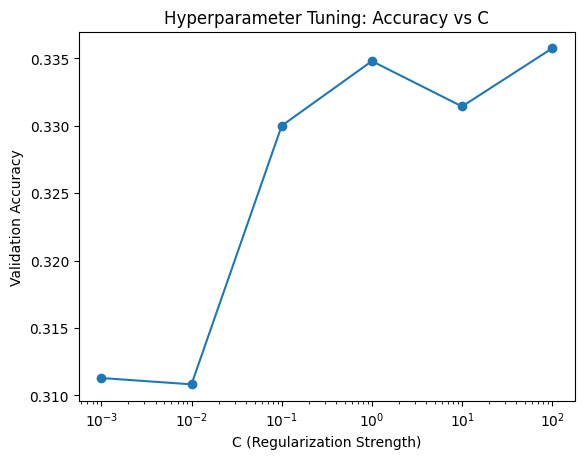

In [11]:
hyperparam_results = pd.DataFrame(grid_search.cv_results_)
plt.semilogx(hyperparam_results['param_logreg__C'], hyperparam_results['mean_test_score'], marker='o')
plt.xlabel('C (Regularization Strength)')
plt.ylabel('Validation Accuracy')
plt.title('Hyperparameter Tuning: Accuracy vs C')
plt.show()

# Checking Model Performance

In [12]:
y_pred = best_model.predict(X_test)
y_predprob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

print()

recall = recall_score(y_test, y_pred)
print("Recall: ", recall)

print()

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)

print()

def calculate_recall_at_k(y_test, y_predprob, k=50):
    y_test = np.array(y_test)
    
    order = np.argsort(y_predprob)[::-1]
    
    y_test_sorted = y_test[order[:k]]
    
    return np.sum(y_test_sorted) / np.sum(y_test)

recall_50 = calculate_recall_at_k(y_test, y_predprob, k=50)
print("Recall@50: ", recall_50)



Accuracy:  0.23953098827470687

Recall:  0.21875

F1 score:  0.2356902356902357

Recall@50:  0.021875


# Confusion Matrix

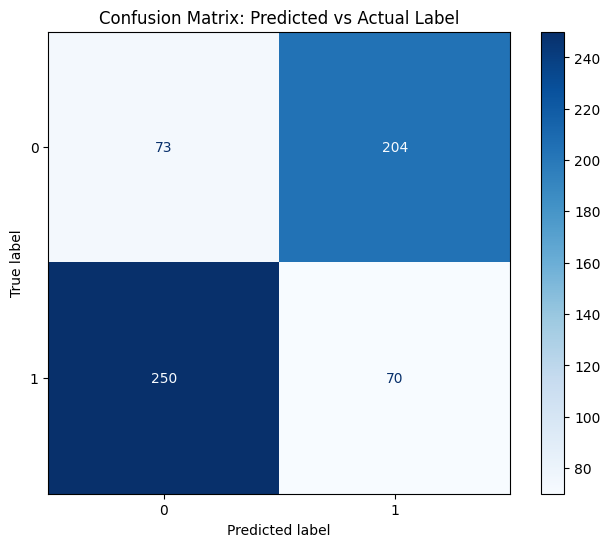

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=grid_search.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs Actual Label')
plt.show()

# Plotting Comparison Graphs

None


C:\Users\advay\AppData\Roaming\Python\Python313\site-packages\IPython\extensions\storemagic.py:148: UserWarning: This is now an optional IPython functionality, using autorestore/recall requires you to install the `pickleshare` library.
  obj = db["autorestore/" + arg]


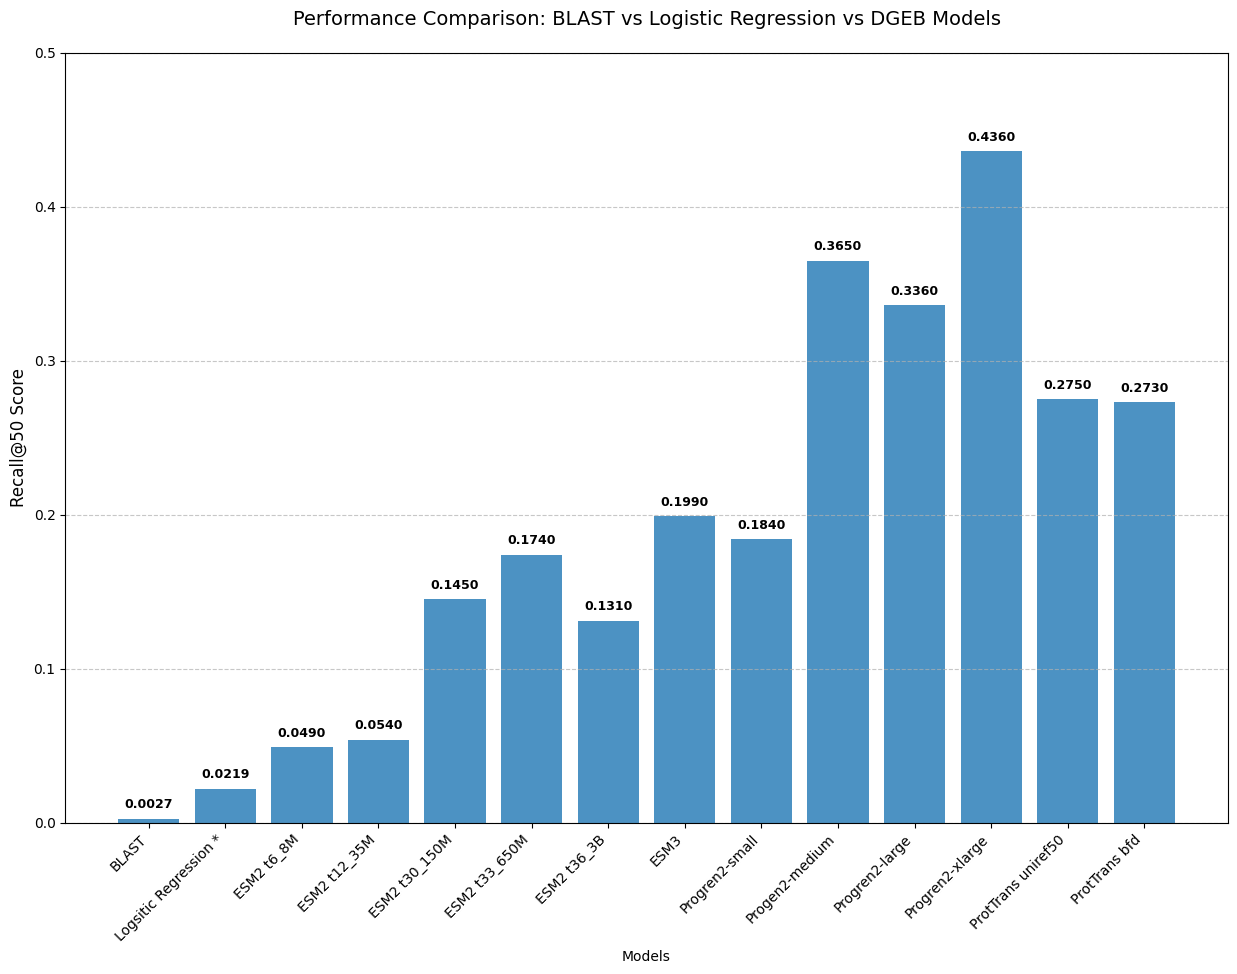

In [14]:
models = ['BLAST', 'Logsitic Regression *', 'ESM2 t6_8M', 'ESM2 t12_35M', 'ESM2 t30_150M', 'ESM2 t33_650M', 'ESM2 t36_3B', 'ESM3', 
          'Progren2-small', 'Progen2-medium', 'Progren2-large', 'Progren2-xlarge', 'ProtTrans uniref50', 'ProtTrans bfd']
%store -r recall
print(recall)
recall50_scores = [0.0027, recall_50, 0.049, 0.054, 0.145, 0.174, 0.131, 0.199, 0.184, 0.365, 0.336, 0.436, 0.275, 0.273]

plt.figure(figsize=(15, 10))
bars = plt.bar(models, recall50_scores, alpha=0.8)

# Add styling
plt.xlabel("Models")
plt.ylabel("Recall@50 Score", fontsize=12)
plt.title("Performance Comparison: BLAST vs Logistic Regression vs DGEB Models", fontsize=14, pad=20)
plt.ylim(0, 0.50)  
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

\* - Logistic Regression is a supervised model while the DGEB models are unsupervised so it is not possible to do an exact one-to-one comparison of our model to the paper